In [1]:
import matplotlib
import numpy as np

from matplotlib import pyplot as plt
from model_tools import ModelAnalysis, RasterAnalysis, make_image


In [2]:
#Set plotting look and feel

host_color = matplotlib.colors.to_rgb('#0000a2')
path_color = matplotlib.colors.to_rgb('#bc272d')
coevol_color = matplotlib.colors.to_rgb('#e9c716')
coevol_color_2 = matplotlib.colors.to_rgb('#50ad9f')

s_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", host_color])
i_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", path_color])

plot_label_size = 10
axis_title_size = 10
axis_label_size = 6
tick_label_size = 6

matplotlib.rcParams['axes.titlesize'] = axis_title_size
matplotlib.rcParams['axes.labelsize'] = axis_label_size
matplotlib.rcParams['xtick.labelsize'] = tick_label_size
matplotlib.rcParams['ytick.labelsize'] = tick_label_size

matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{xfrac}'

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'Helvetica'
})

In [3]:
#Load rasters and data used for raster plots
host_path = 'data_old/host.p'
path_path = 'data_old/path.p'
host_raster = RasterAnalysis(host_path)
path_raster = RasterAnalysis(path_path)

params = {'m':0.5, 'mu':0.2, 'z':5, 'juv_trans':True, 'N_iter':200}

host_model = ModelAnalysis(mode='host', **params)
path_model = ModelAnalysis(mode='path', **params)

In [ ]:
#Load rasters and data used for raster plots
host_path = 'data/default_init_60_host.p'
path_path = 'data/default_init_40_host.p'
host_raster = RasterAnalysis(host_path)
path_raster = RasterAnalysis(path_path)

params = {'m':0.5, 'mu':0.2, 'z':5, 'juv_trans':True, 'N_iter':200}

#host_model = ModelAnalysis(mode='host', **params)
#path_model = ModelAnalysis(mode='path', **params)

Text(-0.1, 1.1, 'C')

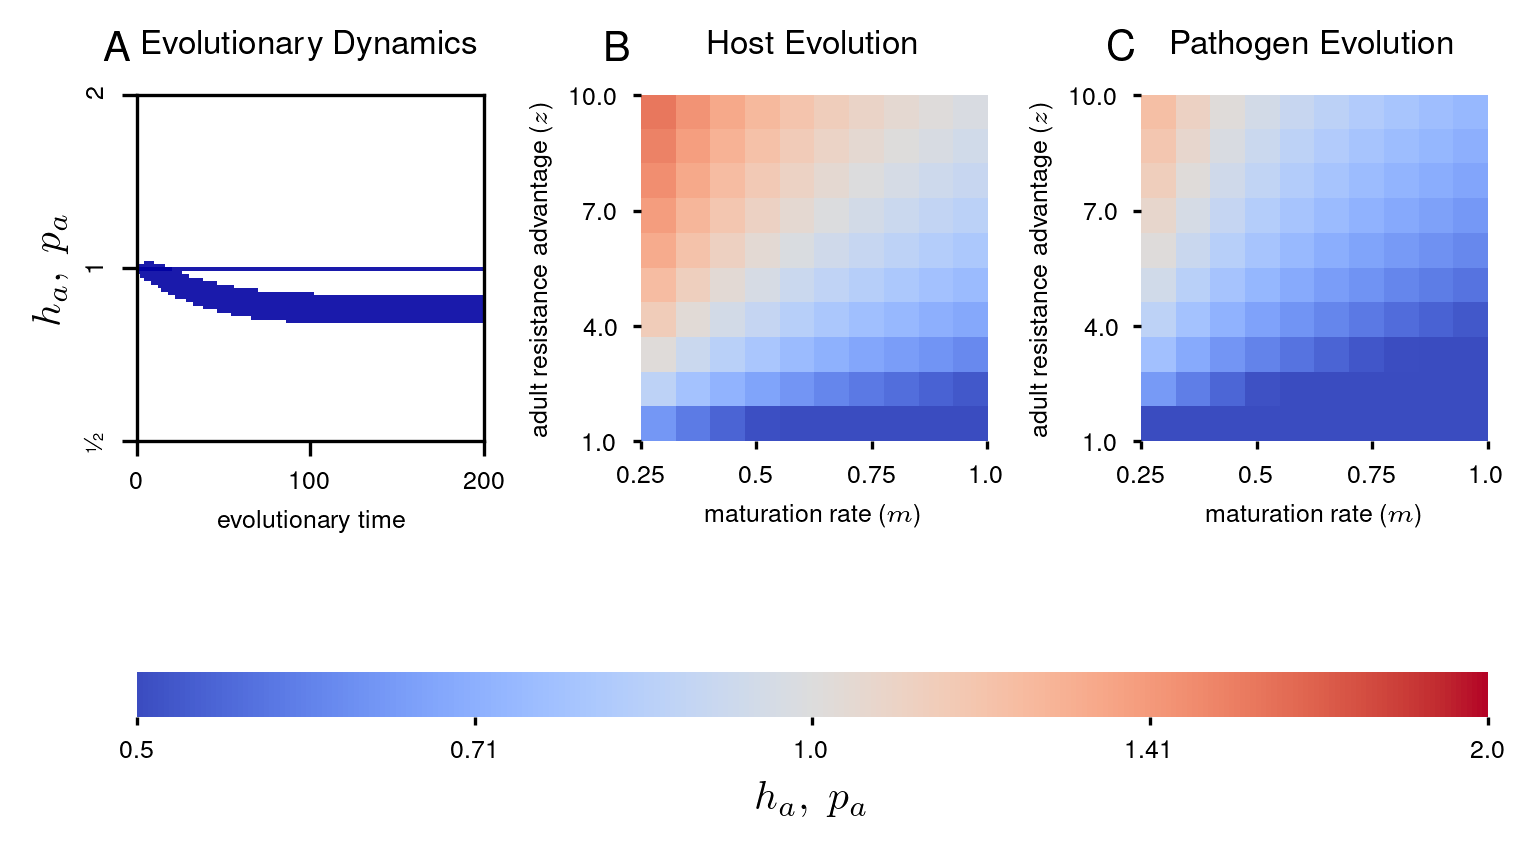

In [ ]:
fig, ax = plt.subplots(figsize=(5,5), ncols=3, nrows=1, layout='compressed')

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, host_model.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

Sa_img_h, Ia_img_h, Sa_alpha_h, Ia_alpha_h = make_image(host_model.Sa, host_model.Ia)
Sa_img_p, Ia_img_p, Sa_alpha_p, Ia_alpha_p = make_image(path_model.Sa, path_model.Ia)

ax[0].imshow(Sa_img_h, alpha=Sa_alpha_h, cmap=s_cmap)
ax[0].imshow(Ia_img_p, alpha=Ia_alpha_p, cmap=i_cmap)

label_x_axis(ax[0])

ax_tick_pos = np.linspace(ax[0].get_ylim()[0], ax[0].get_ylim()[1], 3)
ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']

ax[0].set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)
ax[0].set_ylabel(r'$h_a,\ p_a$', fontsize=10)

S_host, I_host = host_raster.evol_plot()
S_path, I_path, = path_raster.evol_plot()

plot = ax[1].imshow(99 - S_host, cmap='coolwarm', vmin=0, vmax=99)
ax[2].imshow(99 - I_path, cmap='coolwarm', vmin=0, vmax=99)


ax[1].invert_yaxis()
ax[1].set_frame_on(False)
ax[1].tick_params('both', length=2)
ax[2].invert_yaxis()
ax[2].set_frame_on(False)
ax[2].tick_params('both', length=2)

ax[0].set_title('Evolutionary Dynamics', fontsize=8, pad=10)
ax[1].set_title('Host Evolution', fontsize=8,  pad=10)
ax[2].set_title('Pathogen Evolution', fontsize=8, pad=10)

ax[0].set_xlabel(r'evolutionary time')

host_raster.label_axes(ax[1], (4, 4))
path_raster.label_axes(ax[2], (4, 4))


cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
#cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
host_raster = RasterAnalysis(host_path)
path_raster = RasterAnalysis(path_path)

cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure 2: Evolutionary Outcomes #

Text(-0.1, 1.1, 'C')

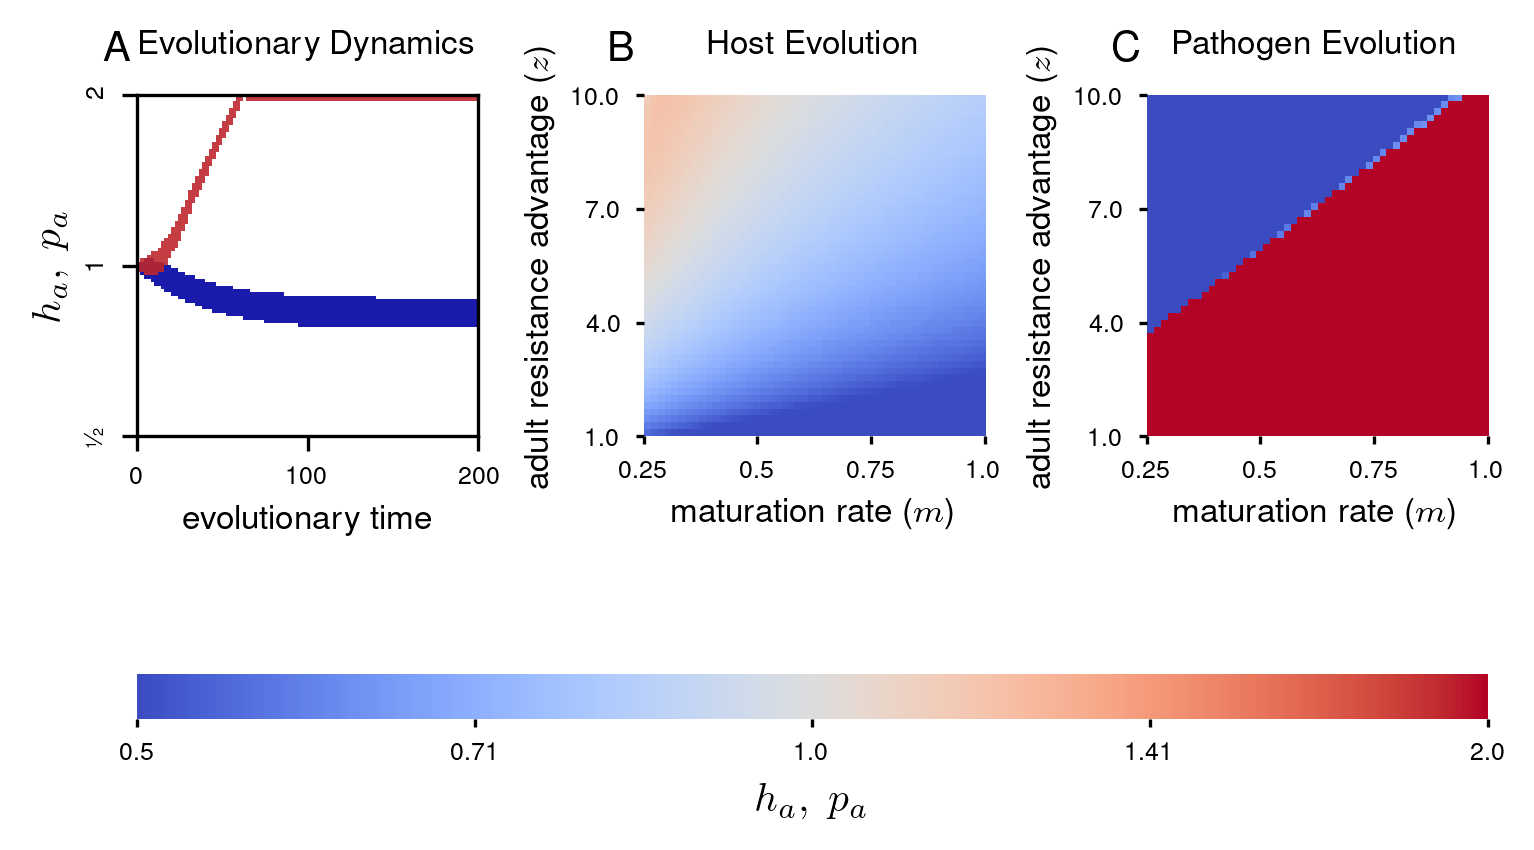

In [4]:
fig, ax = plt.subplots(figsize=(5,5), ncols=3, nrows=1, layout='compressed')

def make_image(Sa, Ia):
    Sa_img = Sa / np.max(Sa)
    Ia_img = Ia / np.max(Ia)
    Sa_img = np.array(Image.fromarray(Sa).resize(size=(100,100)))
    Ia_img = np.array(Image.fromarray(Ia).resize(size=(100,100)))
    Sa_img[Sa_img >= 0.2] = 1
    Sa_img[Sa_img < 0.2] = 0
    Ia_img[Ia_img >= 0.2] = 1
    Ia_img[Ia_img < 0.2] = 0

    Sa_alpha = np.ones(Sa_img.shape)*0.9
    Ia_alpha = np.ones(Ia_img.shape)*0.9
    Sa_alpha[Sa_img == 0] = 0
    Ia_alpha[Ia_img == 0] = 0

    return (Sa_img, Ia_img, Sa_alpha, Ia_alpha)

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, host_model.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

Sa_img_h, Ia_img_h, Sa_alpha_h, Ia_alpha_h = make_image(host_model.Sa, host_model.Ia)
Sa_img_p, Ia_img_p, Sa_alpha_p, Ia_alpha_p = make_image(path_model.Sa, path_model.Ia)

ax[0].imshow(Sa_img_h, alpha=Sa_alpha_h, cmap=s_cmap)
ax[0].imshow(Ia_img_p, alpha=Ia_alpha_p, cmap=i_cmap)

label_x_axis(ax[0])

ax_tick_pos = np.linspace(ax[0].get_ylim()[0], ax[0].get_ylim()[1], 3)
ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']

ax[0].set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)
ax[0].set_ylabel(r'$h_a,\ p_a$', fontsize=10)

S_host, I_host = host_raster.evol_plot()
S_path, I_path, = path_raster.evol_plot()

plot = ax[1].imshow(99 - S_host, cmap='coolwarm', vmin=0, vmax=99)
ax[2].imshow(99 - I_path, cmap='coolwarm', vmin=0, vmax=99)


ax[1].invert_yaxis()
ax[1].set_frame_on(False)
ax[1].tick_params('both', length=2)
ax[2].invert_yaxis()
ax[2].set_frame_on(False)
ax[2].tick_params('both', length=2)

ax[0].set_title('Evolutionary Dynamics', fontsize=8, pad=10)
ax[1].set_title('Host Evolution', fontsize=8,  pad=10)
ax[2].set_title('Pathogen Evolution', fontsize=8, pad=10)

ax[0].set_xlabel(r'evolutionary time')

host_raster.label_axes(ax[1], (4, 4))
path_raster.label_axes(ax[2], (4, 4))


cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
#cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
host_raster = RasterAnalysis(host_path)
path_raster = RasterAnalysis(path_path)

cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure 3: Coevolutionary Outcomes #

In [6]:
params_1 = {'m':0.25, 'z':7, 'mu':0.2, 'juv_trans':True, 'N_iter':200,'Sj_gtp0':50, 'Sa_gtp0':50, 'Ij_gtp0':50,'Ia_gtp0':50}
params_2 = {'m':0.75, 'z':1, 'mu':0.2, 'juv_trans':True, 'N_iter':200,'Sj_gtp0':50, 'Sa_gtp0':50, 'Ij_gtp0':50,'Ia_gtp0':50}
params_3 = {'m':0.75, 'z':2, 'mu':0.2, 'juv_trans':True, 'N_iter':200,'Sj_gtp0':60, 'Sa_gtp0':60, 'Ij_gtp0':60,'Ia_gtp0':60}

model_1 = ModelAnalysis(mode='coevol', **params_1)
model_2 = ModelAnalysis(mode='coevol', **params_2)
model_3 = ModelAnalysis(mode='coevol', **params_3)

def make_image(Sa, Ia):
    Sa_img = Sa / np.max(Sa)
    Ia_img = Ia / np.max(Ia)
    Sa_img = np.array(Image.fromarray(Sa).resize(size=(100,100)))
    Ia_img = np.array(Image.fromarray(Ia).resize(size=(100,100)))
    Sa_img[Sa_img >= 0.2] = 1
    Sa_img[Sa_img < 0.2] = 0
    Ia_img[Ia_img >= 0.2] = 1
    Ia_img[Ia_img < 0.2] = 0

    Sa_alpha = np.ones(Sa_img.shape)*0.9
    Ia_alpha = np.ones(Ia_img.shape)*0.9
    Sa_alpha[Sa_img == 0] = 0
    Ia_alpha[Ia_img == 0] = 0

    return (Sa_img, Ia_img, Sa_alpha, Ia_alpha)

Sa_img_1, Ia_img_1, Sa_alpha_1, Ia_alpha_1 = make_image(model_1.Sa, model_1.Ia)
Sa_img_2, Ia_img_2, Sa_alpha_2, Ia_alpha_2 = make_image(model_2.Sa, model_2.Ia)
Sa_img_3, Ia_img_3, Sa_alpha_3, Ia_alpha_3 = make_image(model_3.Sa, model_3.Ia)

<>:28: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:28: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_3247/3525079780.py:28: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']


Text(-0.1, 1.1, 'C')

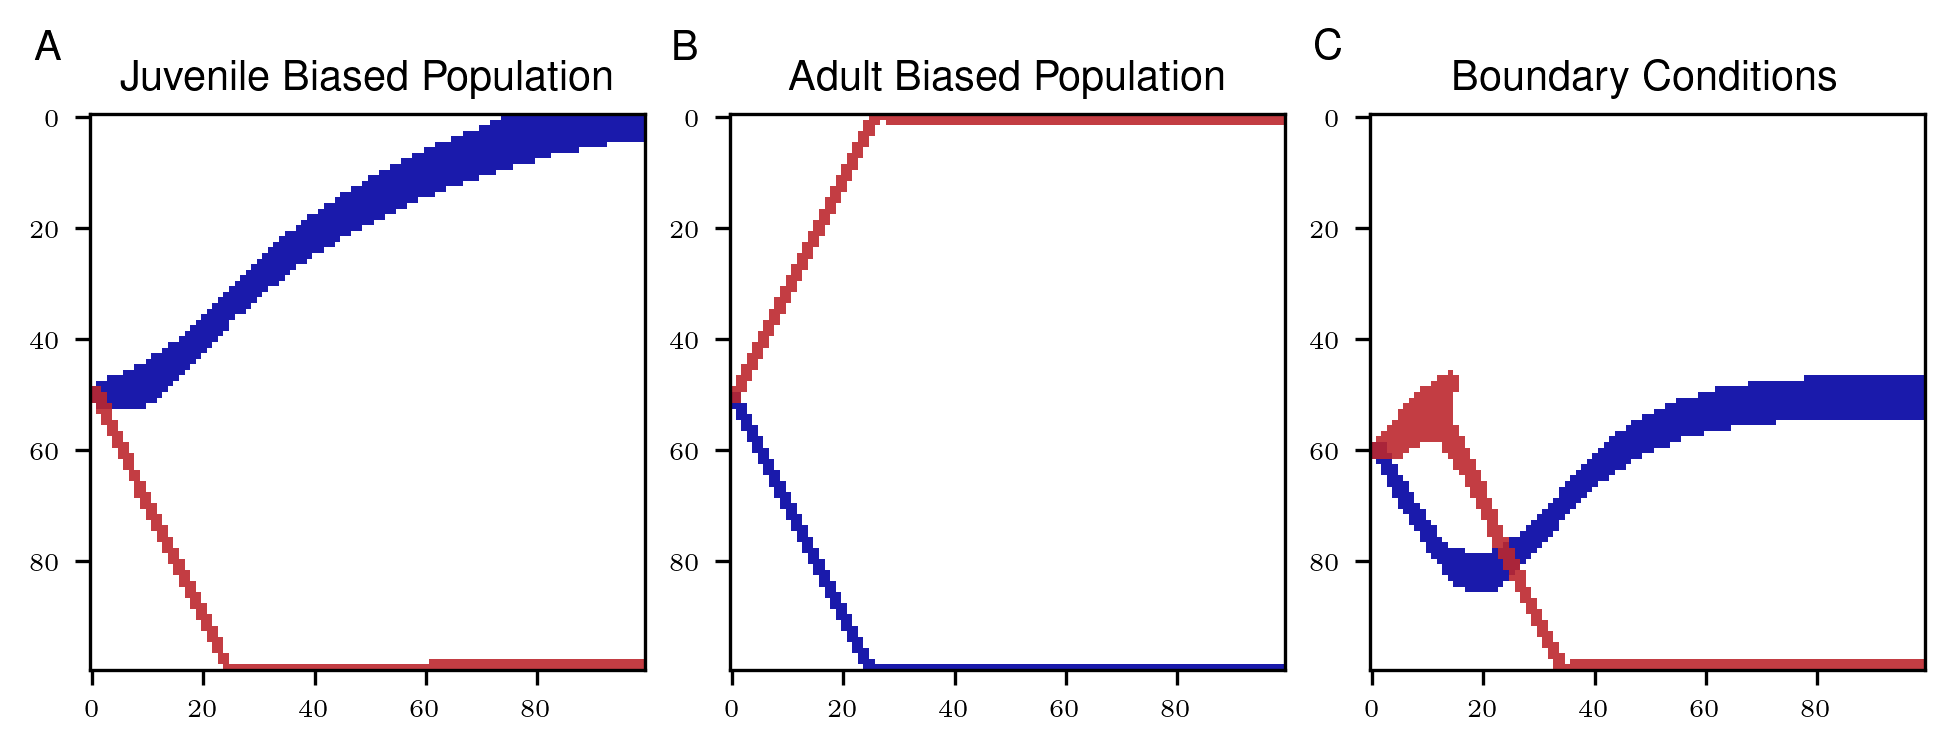

In [8]:
fig, ax = plt.subplots(ncols=3, nrows=1, layout='compressed')

ax[0].imshow(Sa_img_1, alpha=Sa_alpha_1, cmap=s_cmap)
ax[0].imshow(Ia_img_1, alpha=Ia_alpha_1, cmap=i_cmap)
ax[1].imshow(Sa_img_2, alpha=Sa_alpha_2, cmap=s_cmap)
ax[1].imshow(Ia_img_2, alpha=Ia_alpha_2, cmap=i_cmap)
ax[2].imshow(Sa_img_3, alpha=Sa_alpha_3, cmap=s_cmap)
ax[2].imshow(Ia_img_3, alpha=Ia_alpha_3, cmap=i_cmap)

ax[0].set_title('Juvenile Biased Population')
ax[1].set_title('Adult Biased Population')
ax[2].set_title('Boundary Conditions')

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, model_1.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

'''
for axis in ax[0,:]: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    ax_tick_pos = np.linspace(axis.get_ylim()[0], axis.get_ylim()[1], 3)
    ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']
    axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)

    axis.set_xlabel(r'evolutionary time')
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)
'''

ax[0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

# Figure 4: Initial Condition Boundaries #

In [3]:
path_mu2 = 'data_old/init_conds_mu2.p'
path_mu1 = 'data_old/init_conds_mu1.p'
path_z1 = 'data_old/init_conds_z1.p'
path_z5 = 'data_old/init_conds_z5.p'

mu2 = RasterAnalysis(path_mu2, arg_x='Sa_gtp0', arg_y='Ia_gtp0')
mu1 = RasterAnalysis(path_mu1, arg_x='Sa_gtp0', arg_y='Ia_gtp0')
z1 = RasterAnalysis(path_z1, arg_x='Sa_gtp0', arg_y='Ia_gtp0')
z5 = RasterAnalysis(path_z5, arg_x='Sa_gtp0', arg_y='Ia_gtp0')

In [ ]:
#Generate date for evolutionary simulation figures, for branching example use 'm':0.93, 'z':10
params_1 = {'m':0.5, 'z':3, 'mu':0.2, 'juv_trans':True, 'N_iter':200,'Sj_gtp0':40, 'Sa_gtp0':40, 'Ij_gtp0':40,'Ia_gtp0':40}
params_2 = {'m':0.5, 'z':3, 'mu':0.2, 'juv_trans':True, 'N_iter':200,'Sj_gtp0':60, 'Sa_gtp0':60, 'Ij_gtp0':60,'Ia_gtp0':60}

model_1 = ModelAnalysis(mode='coevol', **params_1)
model_2 = ModelAnalysis(mode='coevol', **params_2)

In [5]:
def plot_transition(raster):
    resA = raster.models[0].resA * raster.models[0].z
    infA = raster.models[0].infA / raster.models[0].beta
    S0_inds = np.arange(0, 99, 2)
    I0_inds = np.arange(0, 99, 2)
    S0_vals = resA[S0_inds]
    I0_vals = infA[I0_inds]

    S, I = raster.evol_plot()
    vals = (np.min(I), np.max(I))
    
    S_vals = []
    I_vals = []

    base_val = np.argmin(np.abs(vals - I[0, 0]))

    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            if np.argmin(np.abs(vals - I[j, i])) != base_val:
                S_vals.append(S0_vals[i])
                I_vals.append(I0_vals[j])
                break;

    return S_vals, I_vals

def make_image(Sa, Ia):
    Sa_img = Sa / np.max(Sa)
    Ia_img = Ia / np.max(Ia)
    Sa_img = np.array(Image.fromarray(Sa).resize(size=(100,100)))
    Ia_img = np.array(Image.fromarray(Ia).resize(size=(100,100)))
    Sa_img[Sa_img >= 0.2] = 1
    Sa_img[Sa_img < 0.2] = 0
    Ia_img[Ia_img >= 0.2] = 1
    Ia_img[Ia_img < 0.2] = 0

    Sa_alpha = np.ones(Sa_img.shape)*0.9
    Ia_alpha = np.ones(Ia_img.shape)*0.9
    Sa_alpha[Sa_img == 0] = 0
    Ia_alpha[Ia_img == 0] = 0

    return (Sa_img, Ia_img, Sa_alpha, Ia_alpha)

Sa_img_1, Ia_img_1, Sa_alpha_1, Ia_alpha_1 = make_image(model_1.Sa, model_1.Ia)
Sa_img_2, Ia_img_2, Sa_alpha_2, Ia_alpha_2 = make_image(model_2.Sa, model_2.Ia)

Text(-0.1, 1.1, 'D')

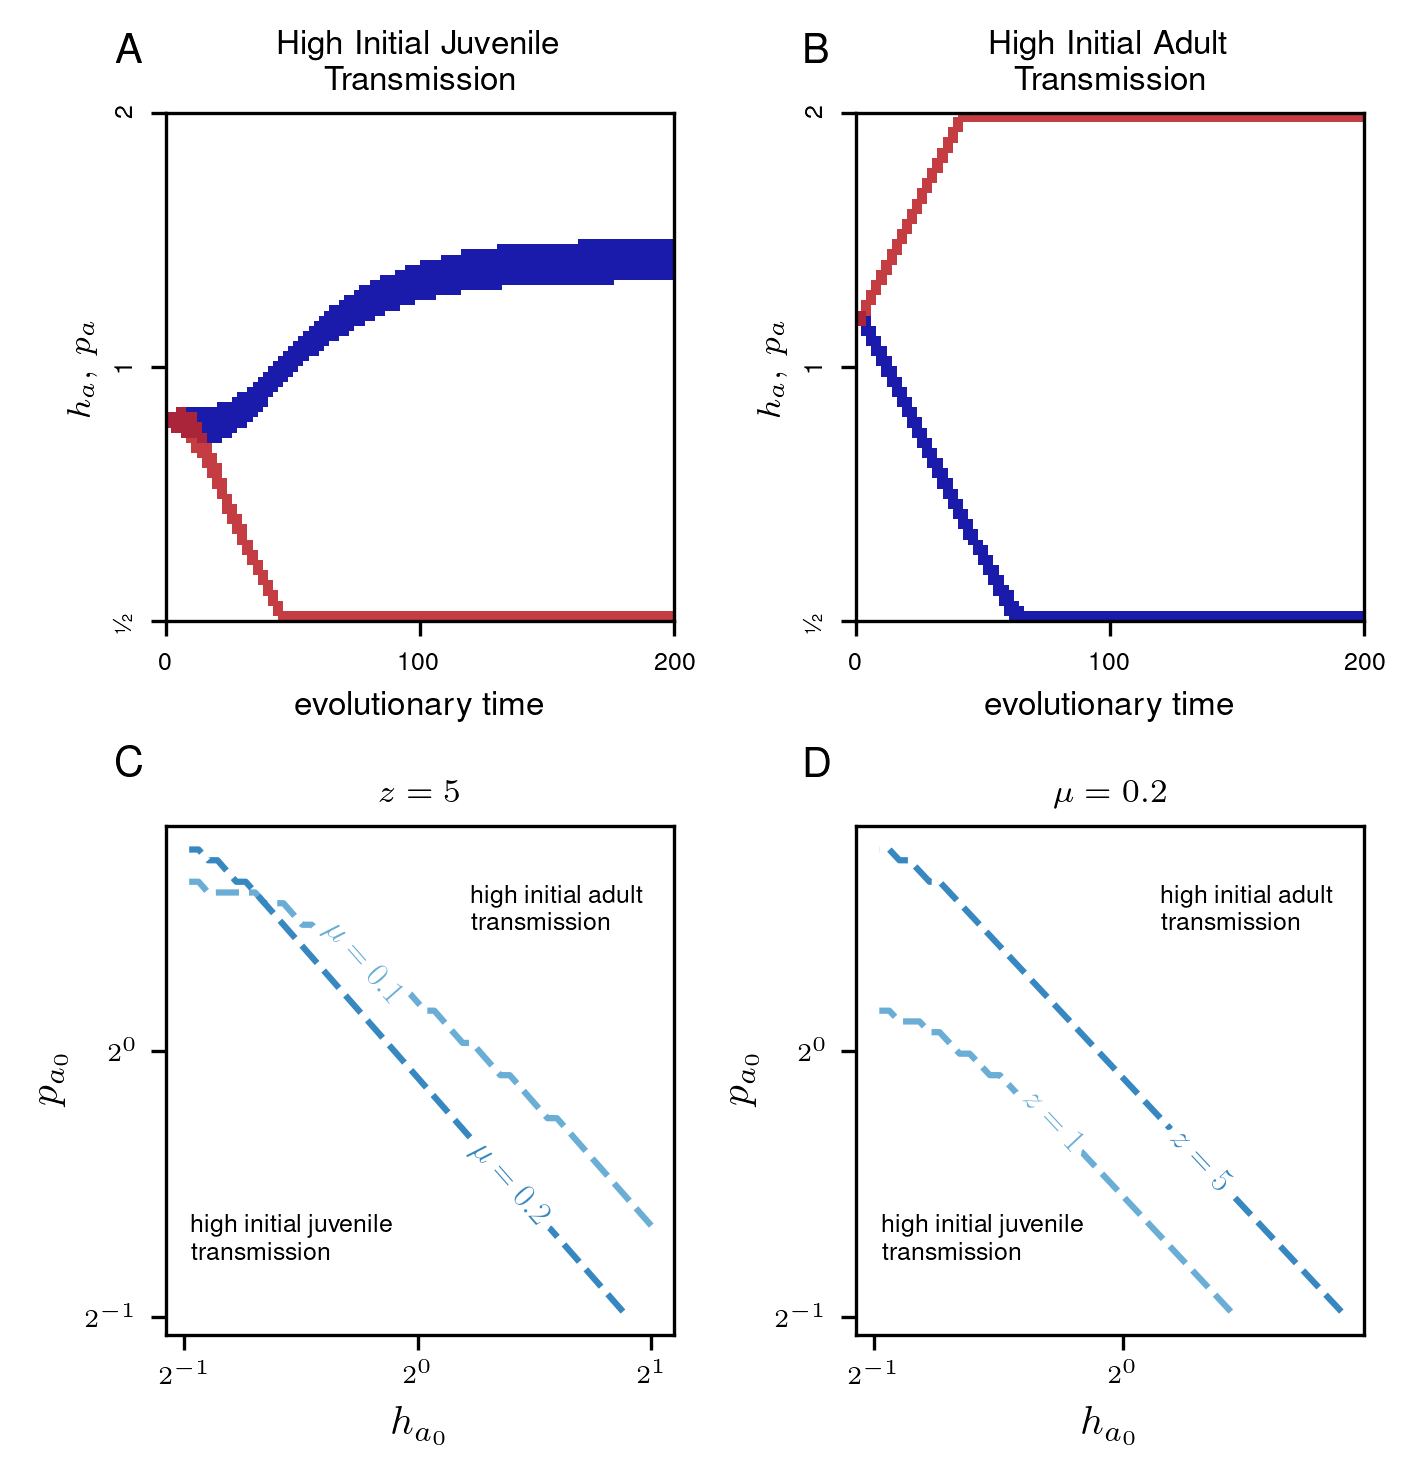

In [8]:
from labellines import labelLine, labelLines

fig, ax = plt.subplots(ncols=2, nrows=2, layout='compressed')

cmap = matplotlib.colormaps['Blues']
colors = cmap(np.linspace(0, 1, 7))
S_mu1, I_mu1 = plot_transition(mu1)
S_mu2, I_mu2 = plot_transition(mu2)
#S_mu3, I_mu3 = plot_transition(mu3)
S_z1, I_z1 = plot_transition(z1)
#S_z3, I_z3 = plot_transition(z3)
S_z5, I_z5 = plot_transition(z5)
#S_z7, I_z7 = plot_transition(z7)

ax[0,0].imshow(Sa_img_2, alpha=Sa_alpha_2, cmap=s_cmap)
ax[0,0].imshow(Ia_img_2, alpha=Ia_alpha_2, cmap=i_cmap)
ax[0,1].imshow(Sa_img_1, alpha=Sa_alpha_1, cmap=s_cmap)
ax[0,1].imshow(Ia_img_1, alpha=Ia_alpha_1, cmap=i_cmap)

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, model_1.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

for axis in ax[0,:]: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    ax_tick_pos = np.linspace(axis.get_ylim()[0], axis.get_ylim()[1], 3)
    ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']
    axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)

    axis.set_xlabel(r'evolutionary time')
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)

ax[0,0].set_title('High Initial Juvenile\nTransmission', fontsize=8)
ax[0,1].set_title('High Initial Adult\nTransmission', fontsize=8)

ax[1,0].set_title(r'$z=5$', fontsize=8)
ax[1,1].set_title(r'$\mu=0.2$', fontsize=8)

ax[1,0].loglog(S_mu1, I_mu1, label=r'$\mu=0.1$', c=colors[3], linestyle='dashed', base=2)
ax[1,0].loglog(S_mu2, I_mu2, label=r'$\mu=0.2$', c=colors[4], linestyle='dashed', base=2)
labelLines(ax[1,0].get_lines(), zorder=2.5, fontsize=8) 


ax[1,1].loglog(S_z1, I_z1, label=r'$z=1$', c=colors[3], linestyle='dashed', base=2)
#ax[1,1].loglog(S_z5, I_z5, label=r'$z=3$', c=colors[4], linestyle='dashed', base=2)
ax[1,1].loglog(S_mu2, I_mu2, label=r'$z=5$', c=colors[4], linestyle='dashed', base=2)
#ax[1,1].loglog(S_z7, I_z7, label=r'$z=7$', c=colors[5], linestyle='dashed', base=2)
labelLines(ax[1,1].get_lines(), zorder=2.5, fontsize=8) 

for axis in ax[1,:]: 
    axis.set_xlabel(r'$h_{a_0}$', fontsize=10)
    axis.set_ylabel(r'$p_{a_0}$', fontsize=10)

    axis.annotate('high initial juvenile\ntransmission',(0.05,0.15), xycoords='axes fraction', fontsize=6)
    axis.annotate('high initial adult\ntransmission', (0.6,0.8), xycoords='axes fraction', fontsize=6)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

# Figure 5: Effects on Infection Prevalence and Demographics #

In [ ]:
coevol_path_jt = 'data/coevol.p'
coevol_path_at = 'data/coevol_adt_init.p'
host_path = 'data/host.p'
path_path = 'data/path.p'

coevol_raster_jt = RasterAnalysis(coevol_path_jt)
coevol_raster_at = RasterAnalysis(coevol_path_at)
host_raster = RasterAnalysis(host_path)
path_raster = RasterAnalysis(path_path)

Text(-0.1, 1.1, 'D')

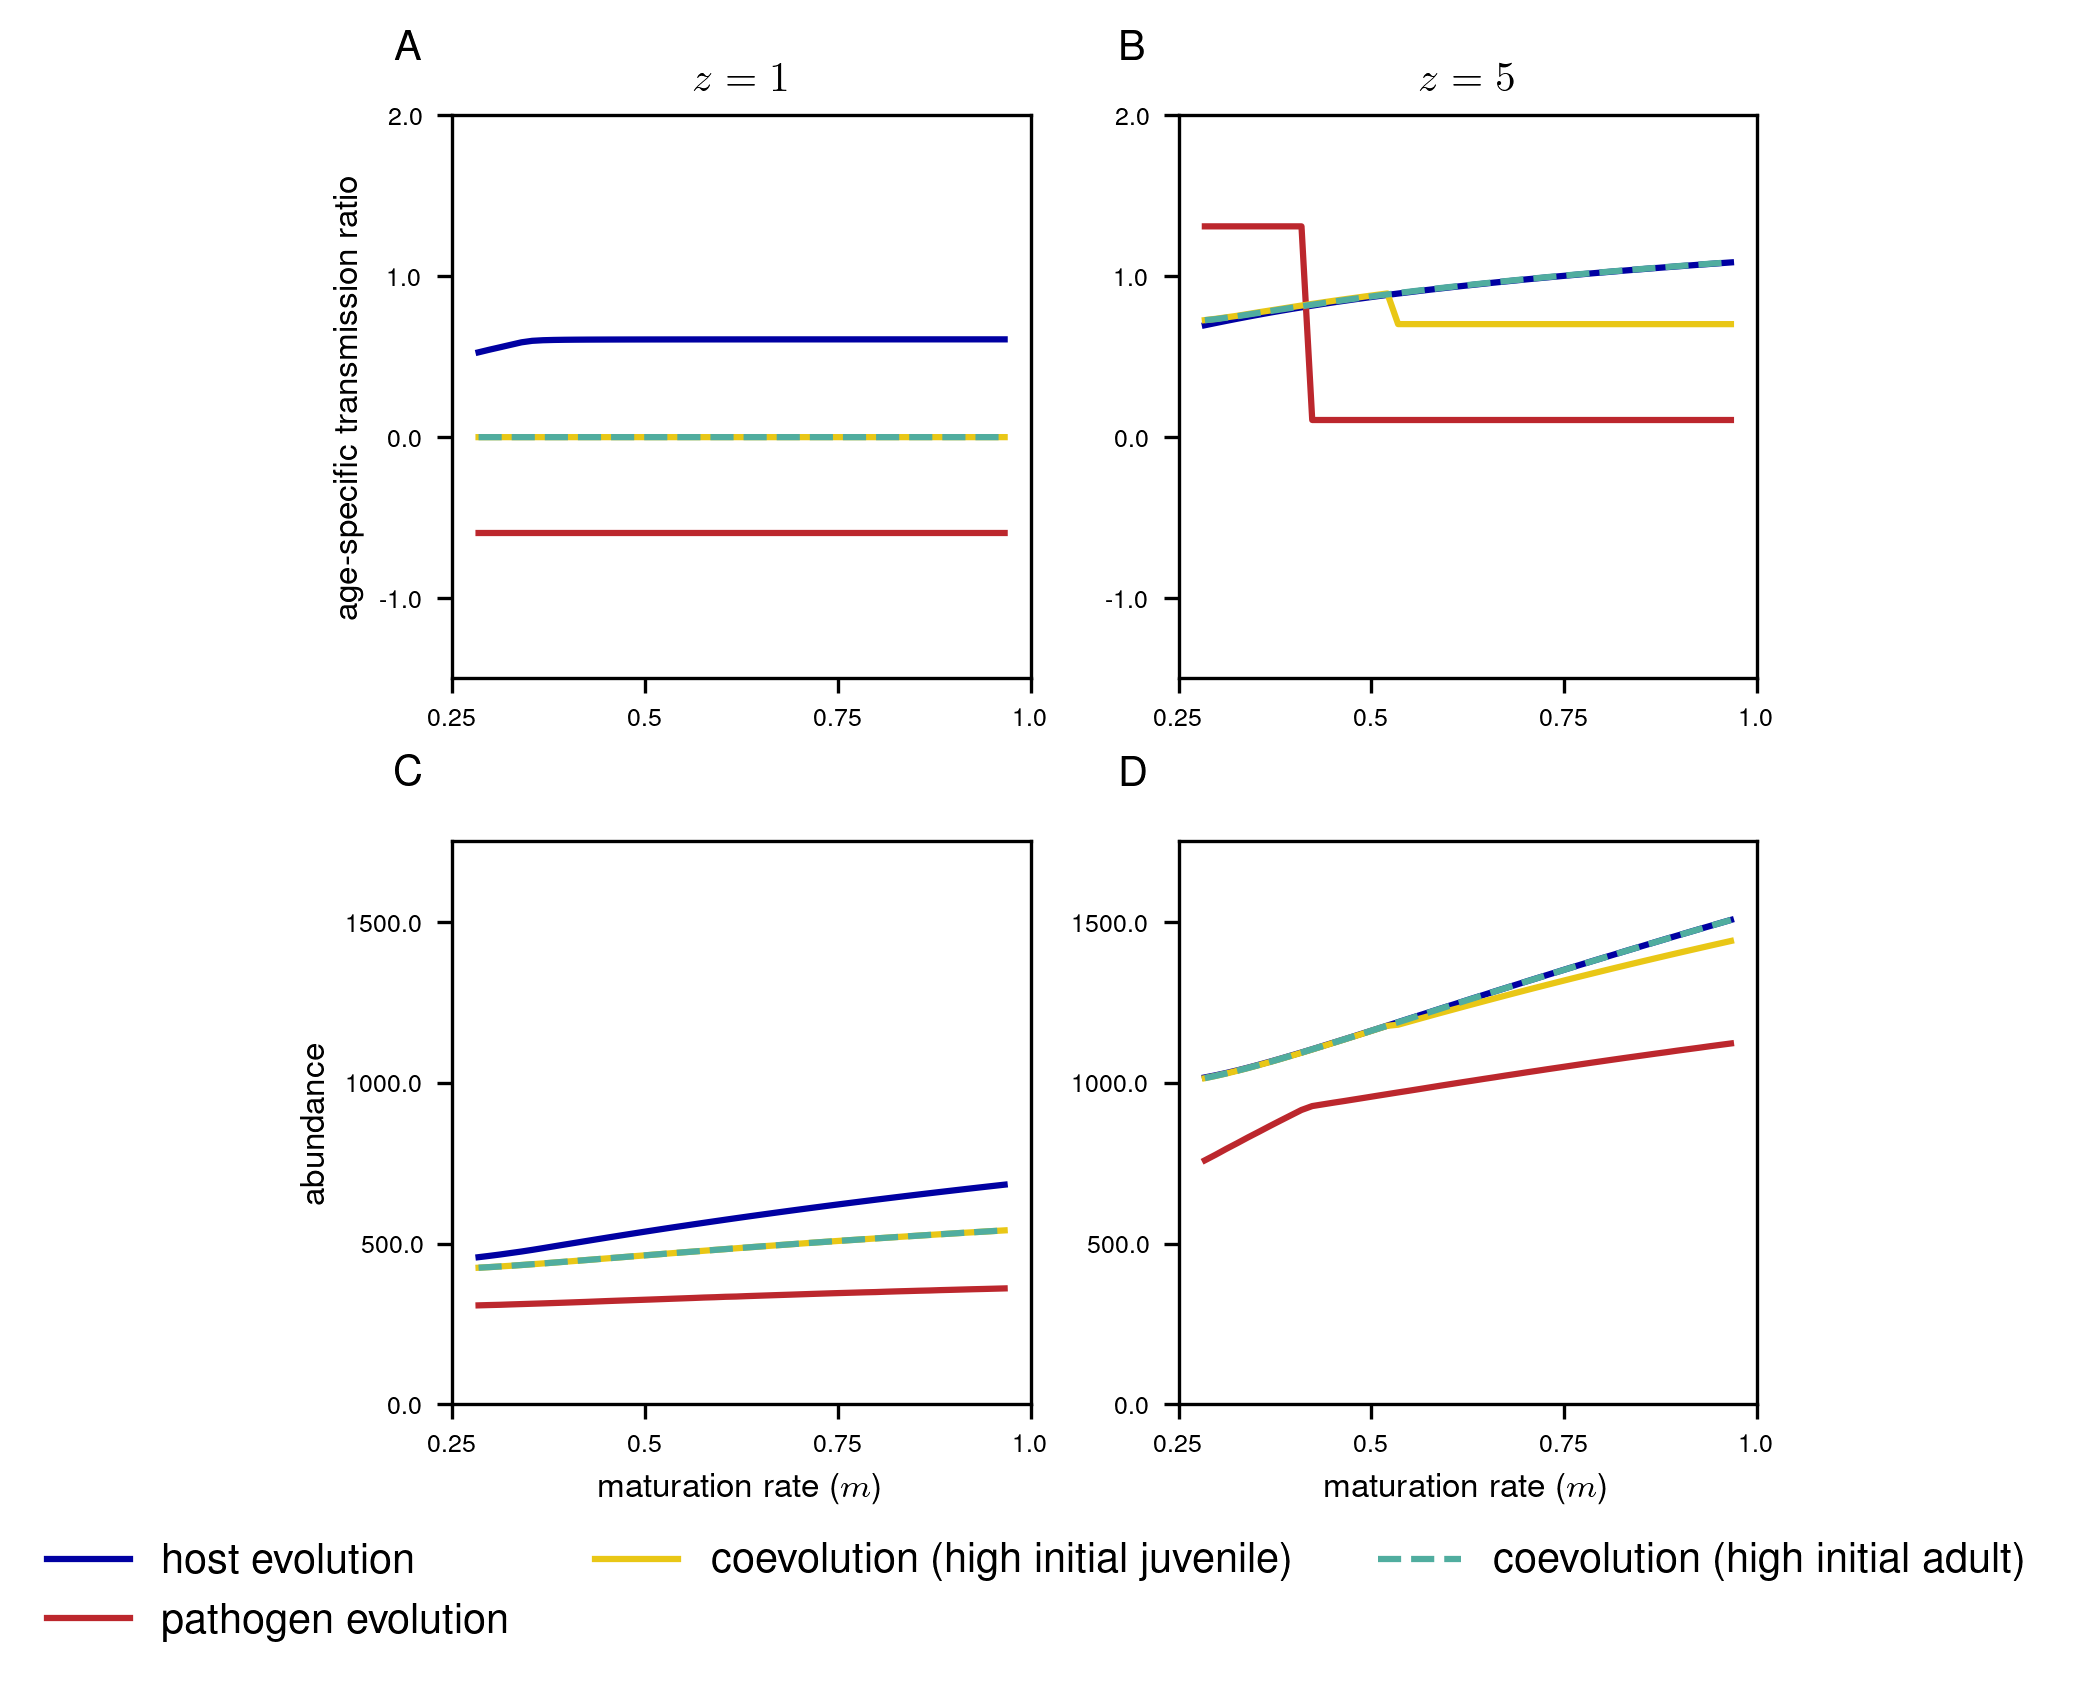

In [6]:
fig, ax = plt.subplots(figsize=(5, 5), ncols=2, nrows=2, layout='compressed')

z_1 = 1
z_2 = 5

ind_1 = np.argmin((coevol_raster_jt.y_vals - z_1)**2)
ind_2 = np.argmin((coevol_raster_jt.y_vals - z_2)**2)

def label_xaxis(ax, n_ticks=4):
    m_vals = coevol_raster_jt.x_vals
    x_lim = ax.get_xlim()

    x_ticks = np.linspace(x_lim[0], x_lim[1], n_ticks)
    x_tick_labels = np.round(np.linspace(np.min(m_vals), np.max(m_vals), n_ticks), 3)
    
    ax.set_xticks(x_ticks, x_tick_labels)

betaj_host, betaa_host = host_raster.mean_transmission()
betaj_path, betaa_path = path_raster.mean_transmission()
betaj_coevol_jt, betaa_coevol_jt = coevol_raster_jt.mean_transmission()
betaj_coevol_at, betaa_coevol_at = coevol_raster_at.mean_transmission()


host_ratio = np.log10(betaj_host / betaa_host)
path_ratio = np.log10(betaj_path / betaa_path)
coevol_ratio_jt = np.log10(betaj_coevol_jt / betaa_coevol_jt)
coevol_ratio_at = np.log10(betaj_coevol_at / betaa_coevol_at)


Sj_h, Sa_h, Ij_h, Ia_h = host_raster.abundance()
Sj_p, Sa_p, Ij_p, Ia_p = path_raster.abundance()
Sj_jtc, Sa_jtc, Ij_jtc, Ia_jtc = coevol_raster_jt.abundance()
Sj_atc, Sa_atc, Ij_atc, Ia_atc = coevol_raster_at.abundance()


ax[0,0].plot(host_ratio[ind_1,:], label='host evolution', color=host_color)
ax[0,0].plot(path_ratio[ind_1,:], label='pathogen evolution', color=path_color)
ax[0,0].plot(coevol_ratio_jt[ind_1,:], label='coevolution (high initial juvenile)', color=coevol_color)
ax[0,0].plot(coevol_ratio_at[ind_1,:], label='coevolution (high initial adult)', color=coevol_color_2, linestyle='--')


ax[0,1].plot(host_ratio[ind_2,:], label='host evolution', color=host_color)
ax[0,1].plot(path_ratio[ind_2,:], label='pathogen evolution', color=path_color)
ax[0,1].plot(coevol_ratio_jt[ind_2,:], label='coevolution (high initial juvenile)', color=coevol_color)
ax[0,1].plot(coevol_ratio_at[ind_2,:], label='coevolution (high initial adult)', color=coevol_color_2, linestyle='--')

ax[1,0].plot((Sj_h+Sa_h+Ij_h+Ia_h)[ind_1,:], label='host evolution', color=host_color)
ax[1,0].plot((Sj_p+Sa_p+Ij_p+Ia_p)[ind_1,:], label='pathogen evolution', color=path_color)
ax[1,0].plot((Sj_jtc+Sa_jtc+Ij_jtc+Ia_jtc)[ind_1,:], label='coevolution (high initial juvenile)', color=coevol_color)
ax[1,0].plot((Sj_atc+Sa_atc+Ij_atc+Ia_atc)[ind_1,:], label='coevolution (high initial adult)', color=coevol_color_2, linestyle='--')


ax[1,1].plot((Sj_h+Sa_h+Ij_h+Ia_h)[ind_2,:], label='host evolution', color=host_color)
ax[1,1].plot((Sj_p+Sa_p+Ij_p+Ia_p)[ind_2,:], label='pathogen evolution', color=path_color)
ax[1,1].plot((Sj_jtc+Sa_jtc+Ij_jtc+Ia_jtc)[ind_2,:], label='coevolution (high initial juvenile)', color=coevol_color)
ax[1,1].plot((Sj_atc+Sa_atc+Ij_atc+Ia_atc)[ind_2,:], label='coevolution (high initial adult)', color=coevol_color_2, linestyle='--')


#ax[1,0].plot((Ij_h + Ia_h)[ind_1,:], linestyle='--', label='host evolution', color=host_color)
#ax[1,0].plot((Ij_p + Ia_p)[ind_1,:], linestyle='--', label='pathogen evolution', color=path_color)
#ax[1,0].plot((Ij_c + Ia_c)[ind_1,:], linestyle='--', label='coevolution', color=coevol_color)

#ax[1,1].plot((Ij_h + Ia_h)[ind_2,:], linestyle='--', label='host evolution', color=host_color)
#ax[1,1].plot((Ij_p + Ia_p)[ind_2,:], linestyle='--', label='pathogen evolution', color=path_color)
#ax[1,1].plot((Ij_c + Ia_c)[ind_2,:], linestyle='--', label='coevolution', color=coevol_color)

ax[0,0].set_ylim(-1.5, 2)
ax[0,1].set_ylim(-1.5, 2)

ax[1,0].set_ylim(0, 1750)
ax[1,1].set_ylim(0, 1750)

for axis in ax.reshape(-1):
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.1f'))

ax[0,0].set_title(r'$z=1$')
ax[0,1].set_title(r'$z=5$')

ax[0,0].set_ylabel('age-specific transmission ratio')
ax[1,0].set_ylabel('abundance')

ax[1,0].set_xlabel(r'maturation rate ($m$)')
ax[1,1].set_xlabel(r'maturation rate ($m$)')

for axis in ax.reshape(-1): label_xaxis(axis)

lines, labels = ax[0,0].get_legend_handles_labels()
fig.legend(lines, labels, ncol=3, loc='center', bbox_to_anchor=(0.5, -0.05), frameon=False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)